# (CNN) - Clasificador de Animales
### Clases: Ranas, Pájaros, Ballenas, Changos, Arañas


# 1. Importar Librerías

In [25]:
import numpy as np
import os
import re
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization, Input
)
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

print('TensorFlow version:', tf.__version__)
print('Keras version:', keras.__version__)

TensorFlow version: 2.21.0
Keras version: 3.13.2


# 2. Cargar Imágenes del Dataset

**Estructura esperada de carpetas:**
```
/home/adolfolinares/OIDv4_ToolKitDataset_Final/
├── ranas/       (20,000 imágenes)
├── pajaros/     (20,000 imágenes)
├── ballenas/    (20,000 imágenes)
├── changos/     (20,000 imágenes)
└── arañas/      (20,000 imágenes)
```

In [26]:
# Ruta a la carpeta principal del dataset
dirname = os.path.join(os.getcwd(), 'Dataset_Final')
imgpath = dirname + os.sep

images = []
labels = []

clases_nombres = ['ranas', 'pajaros', 'ballenas', 'changos', 'arañas']

print("Leyendo imágenes de:", imgpath)
print("-" * 50)

dircount = []

for idx, clase in enumerate(clases_nombres):
    folder = os.path.join(imgpath, clase)

    if not os.path.exists(folder):
        print(f"⚠️  ALERTA: No se encontró la carpeta '{clase}' en {folder}")
        continue

    contador = 0
    for filename in os.listdir(folder):
        if re.search(r"\.(jpg|jpeg|png|bmp)$", filename, re.IGNORECASE):
            filepath = os.path.join(folder, filename)

            image = cv2.imread(filepath)
            if image is not None:
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                image = cv2.resize(image, (35, 35))
                images.append(image)
                labels.append(idx)
                contador += 1

    dircount.append(contador)
    print(f"Clase {idx} - {clase}: {contador} imágenes cargadas")

print("-" * 50)
print(f'✅ Total de imágenes cargadas: {len(images)}')

Leyendo imágenes de: /home/adolfolinares/OIDv4_ToolKit/Dataset_Final/
--------------------------------------------------
Clase 0 - ranas: 20000 imágenes cargadas
Clase 1 - pajaros: 20000 imágenes cargadas
Clase 2 - ballenas: 20000 imágenes cargadas
Clase 3 - changos: 20000 imágenes cargadas
Clase 4 - arañas: 20000 imágenes cargadas
--------------------------------------------------
✅ Total de imágenes cargadas: 100000


# 3. Verificar Equilibrio del Dataset

=== EQUILIBRIO DEL DATASET ===
----------------------------------------
Clase 0 | ranas      |  20000 imágenes | ████████████████████
Clase 1 | pajaros    |  20000 imágenes | ████████████████████
Clase 2 | ballenas   |  20000 imágenes | ████████████████████
Clase 3 | changos    |  20000 imágenes | ████████████████████
Clase 4 | arañas     |  20000 imágenes | ████████████████████
----------------------------------------
Total: 100000 imágenes
✅ Dataset BALANCEADO


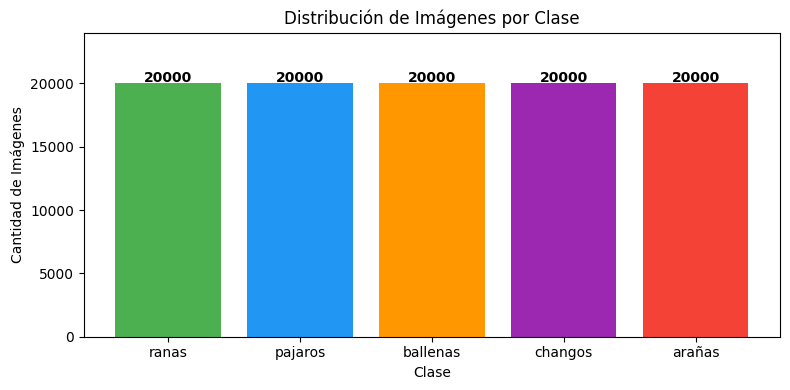

In [27]:
print("=== EQUILIBRIO DEL DATASET ===")
print("-" * 40)
for i, (clase, cantidad) in enumerate(zip(clases_nombres, dircount)):
    barra = '█' * (cantidad // 1000)
    print(f"Clase {i} | {clase:<10} | {cantidad:>6} imágenes | {barra}")

print("-" * 40)
total = sum(dircount)
print(f"Total: {total} imágenes")

min_clase = min(dircount)
max_clase = max(dircount)
if max_clase - min_clase <= 100:
    print("✅ Dataset BALANCEADO")
else:
    print(f"⚠️  Dataset DESBALANCEADO (mín: {min_clase}, máx: {max_clase})")

plt.figure(figsize=(8, 4))
plt.bar(clases_nombres, dircount,
        color=['#4CAF50','#2196F3','#FF9800','#9C27B0','#F44336'])
plt.title('Distribución de Imágenes por Clase')
plt.xlabel('Clase')
plt.ylabel('Cantidad de Imágenes')
plt.ylim(0, max(dircount) * 1.2)
for i, v in enumerate(dircount):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# 4. Convertir a Matrices Numpy

In [28]:
y = np.array(labels)
X = np.array(images, dtype=np.uint8)

classes  = np.unique(y)
nClasses = len(classes)

print(f'Forma de X (imágenes): {X.shape}')  
print(f'Forma de y (etiquetas): {y.shape}')
print(f'Número de clases: {nClasses}')
print(f'Canales de color: {X.shape[3]} (3 = RGB)')

Forma de X (imágenes): (100000, 35, 35, 3)
Forma de y (etiquetas): (100000,)
Número de clases: 5
Canales de color: 3 (3 = RGB)


# 5. Dividir en Sets de Entrenamiento y Prueba

In [29]:
train_X, test_X, train_Y, test_Y = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Entrenamiento: {train_X.shape}  |  Prueba: {test_X.shape}')

Entrenamiento: (80000, 35, 35, 3)  |  Prueba: (20000, 35, 35, 3)


# 6. Visualizar Ejemplos del Dataset

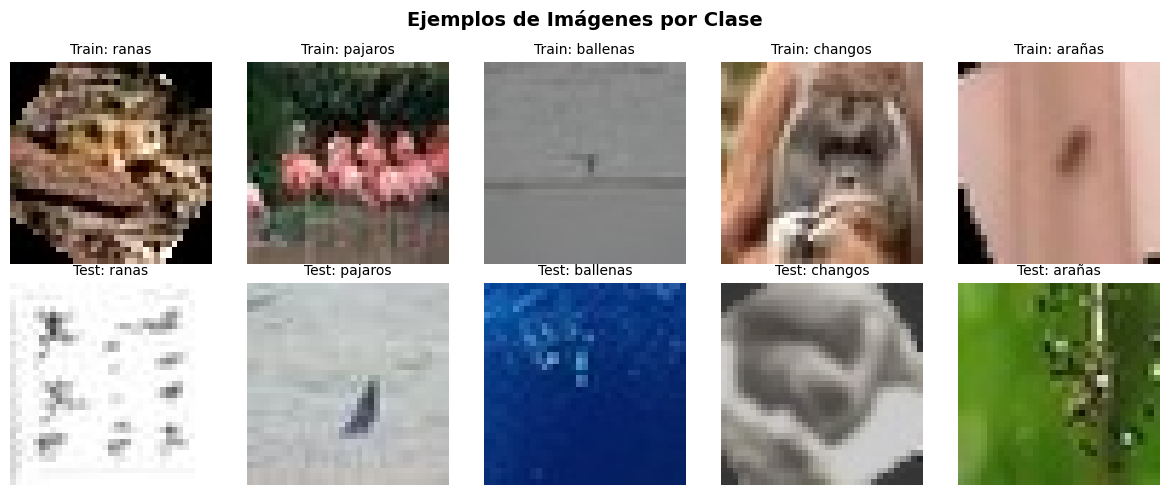

In [30]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Ejemplos de Imágenes por Clase', fontsize=14, fontweight='bold')

for clase_idx in range(nClasses):
    idx  = np.where(train_Y == clase_idx)[0][0]
    idx2 = np.where(test_Y  == clase_idx)[0][0]

    axes[0, clase_idx].imshow(train_X[idx])
    axes[0, clase_idx].set_title(f'Train: {clases_nombres[clase_idx]}', fontsize=10)
    axes[0, clase_idx].axis('off')

    axes[1, clase_idx].imshow(test_X[idx2])
    axes[1, clase_idx].set_title(f'Test: {clases_nombres[clase_idx]}', fontsize=10)
    axes[1, clase_idx].axis('off')

plt.tight_layout()
plt.show()

# 7. Preprocesar las Imágenes (Normalización)

In [31]:
# Normalizar entre 0 y 1
train_X = train_X.astype('float32') / 255.0
test_X  = test_X.astype('float32')  / 255.0

print(f'Shape final train: {train_X.shape}')   # (N, 35, 35, 3)
print(f'Rango: Mín={train_X.min():.2f}, Máx={train_X.max():.2f}')
print('✅ Normalización correcta')

Shape final train: (80000, 35, 35, 3)
Rango: Mín=0.00, Máx=1.00
✅ Normalización correcta


# 8. Encoding de Etiquetas

In [32]:
train_Y_one_hot = to_categorical(train_Y, num_classes=nClasses)
test_Y_one_hot  = to_categorical(test_Y,  num_classes=nClasses)

print('Ejemplo one-hot:', train_Y_one_hot[0], '->', clases_nombres[train_Y[0]])

Ejemplo one-hot: [0. 0. 0. 0. 1.] -> arañas


# 9. Crear Set de Validación

In [33]:
train_X, valid_X, train_label, valid_label = train_test_split(
    train_X, train_Y_one_hot, test_size=0.2, random_state=48
)

print(f'Entrenamiento: {train_X.shape}')
print(f'Validación:    {valid_X.shape}')
print(f'Prueba:        {test_X.shape}')

Entrenamiento: (64000, 35, 35, 3)
Validación:    (16000, 35, 35, 3)
Prueba:        (20000, 35, 35, 3)


# 10. Parámetros de Entrenamiento

In [34]:
INIT_LR    = 1e-3
epochs     = 50
batch_size = 64

# 11. Crear el Modelo CNN 


In [35]:
# =============================================
#   ARQUITECTURA CNN - 2 CAPAS CONVOLUCIONALES
#   Entrada: 35x35x3  (COLOR RGB)
# =============================================
sport_model = Sequential(name='CNN_Animales_Color')

sport_model.add(Input(shape=(35, 35, 3)))

# --- CAPA CONVOLUCIONAL 1 ---
sport_model.add(Conv2D(64, kernel_size=(3, 3), activation='linear', padding='same'))
sport_model.add(BatchNormalization())
sport_model.add(LeakyReLU(negative_slope=0.1))
sport_model.add(MaxPooling2D((2, 2), padding='same'))
sport_model.add(Dropout(0.25))

# --- CAPA CONVOLUCIONAL 2 ---
sport_model.add(Conv2D(128, kernel_size=(3, 3), activation='linear', padding='same'))
sport_model.add(BatchNormalization())
sport_model.add(LeakyReLU(negative_slope=0.1))
sport_model.add(MaxPooling2D((2, 2), padding='same'))
sport_model.add(Dropout(0.25))

# --- CAPAS DENSAS ---
sport_model.add(Flatten())
sport_model.add(Dense(256, activation='linear'))
sport_model.add(BatchNormalization())
sport_model.add(LeakyReLU(negative_slope=0.1))
sport_model.add(Dropout(0.5))
sport_model.add(Dense(nClasses, activation='softmax'))

sport_model.summary()

Model: "CNN_Animales_Color"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 35, 35, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 35, 35, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 35, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 18, 18, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 18, 18, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,654,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,733,189 (10.43 MB)

 Trainable params: 2,732,293 (10.42 MB)

 Non-trainable params: 896 (3.50 KB)

# 12. Compilar el Modelo

In [36]:
sport_model.compile(
    loss=keras.losses.categorical_crossentropy,
    optimizer=tf.keras.optimizers.Adam(learning_rate=INIT_LR),
    metrics=['accuracy']
)
print('✅ Modelo compilado correctamente')

✅ Modelo compilado correctamente


# 13. Entrenar el Modelo

> ⏳ Puede tardar varios minutos. Se guarda automáticamente el **mejor** modelo.

In [37]:
checkpoint = ModelCheckpoint(
    'modelo_animales_final.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

sport_train = sport_model.fit(
    train_X, train_label,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(valid_X, valid_label),
    callbacks=[checkpoint, early_stop]
)

print('\n✅ Entrenamiento finalizado')

Epoch 1/50


W0000 00:00:1778606924.584655  111814 cpu_allocator_impl.cc:82] Allocation of 940800000 exceeds 10% of free system memory.


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.6104 - loss: 1.0035

W0000 00:00:1778607093.539447  111814 cpu_allocator_impl.cc:82] Allocation of 235200000 exceeds 10% of free system memory.



Epoch 1: val_accuracy improved from None to 0.71887, saving model to modelo_animales_final.keras

Epoch 1: finished saving model to modelo_animales_final.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 177s 175ms/step - accuracy: 0.6752 - loss: 0.8361 - val_accuracy: 0.7189 - val_loss: 0.7066
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.7530 - loss: 0.6389
Epoch 2: val_accuracy improved from 0.71887 to 0.72462, saving model to modelo_animales_final.keras

Epoch 2: finished saving model to modelo_animales_final.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 181s 181ms/step - accuracy: 0.7580 - loss: 0.6243 - val_accuracy: 0.7246 - val_loss: 0.7732
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.7851 - loss: 0.5578
Epoch 3: val_accuracy improved from 0.72462 to 0.78931, saving model to modelo_animales_final.keras

Epoch 3: finished saving model to modelo_animales_final.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 170s 170ms/step - accuracy: 0.7853 - loss: 0.5562 - val_

# 14. Evaluar el Modelo

In [38]:
test_eval = sport_model.evaluate(test_X, test_Y_one_hot, verbose=1)
print(f'\nPérdida (Loss):   {test_eval[0]:.4f}')
print(f'Precisión (Acc):  {test_eval[1]*100:.2f}%')

W0000 00:00:1778610582.974559  111814 cpu_allocator_impl.cc:82] Allocation of 294000000 exceeds 10% of free system memory.


625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.8271 - loss: 0.4422

Pérdida (Loss):   0.4422
Precisión (Acc):  82.71%


# 15. Gráficas de Entrenamiento

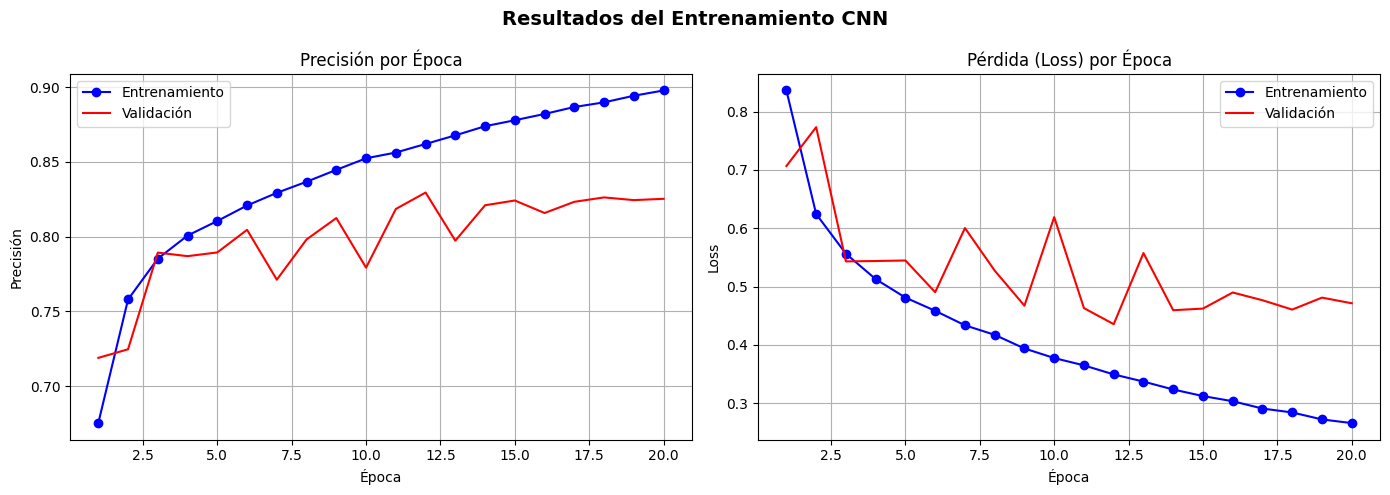

In [39]:
accuracy     = sport_train.history['accuracy']
val_accuracy = sport_train.history['val_accuracy']
loss         = sport_train.history['loss']
val_loss     = sport_train.history['val_loss']
epocas_rango = range(1, len(accuracy) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epocas_rango, accuracy,     'bo-', label='Entrenamiento')
ax1.plot(epocas_rango, val_accuracy, 'r-',  label='Validación')
ax1.set_title('Precisión por Época')
ax1.set_xlabel('Época')
ax1.set_ylabel('Precisión')
ax1.legend()
ax1.grid(True)

ax2.plot(epocas_rango, loss,     'bo-', label='Entrenamiento')
ax2.plot(epocas_rango, val_loss, 'r-',  label='Validación')
ax2.set_title('Pérdida (Loss) por Época')
ax2.set_xlabel('Época')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.suptitle('Resultados del Entrenamiento CNN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 16. Reporte de Clasificación

In [40]:
predicted_probs   = sport_model.predict(test_X)
predicted_classes = np.argmax(predicted_probs, axis=1)

print("=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(test_Y, predicted_classes, target_names=clases_nombres))

W0000 00:00:1778610596.729300  111814 cpu_allocator_impl.cc:82] Allocation of 294000000 exceeds 10% of free system memory.


625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step
=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

       ranas       0.78      0.78      0.78      4000
     pajaros       0.85      0.89      0.87      4000
    ballenas       0.85      0.97      0.91      4000
     changos       0.82      0.75      0.78      4000
      arañas       0.83      0.75      0.79      4000

    accuracy                           0.83     20000
   macro avg       0.83      0.83      0.83     20000
weighted avg       0.83      0.83      0.83     20000



# 17. Ver Aciertos y Errores

Correctas:   16543
Incorrectas: 3457


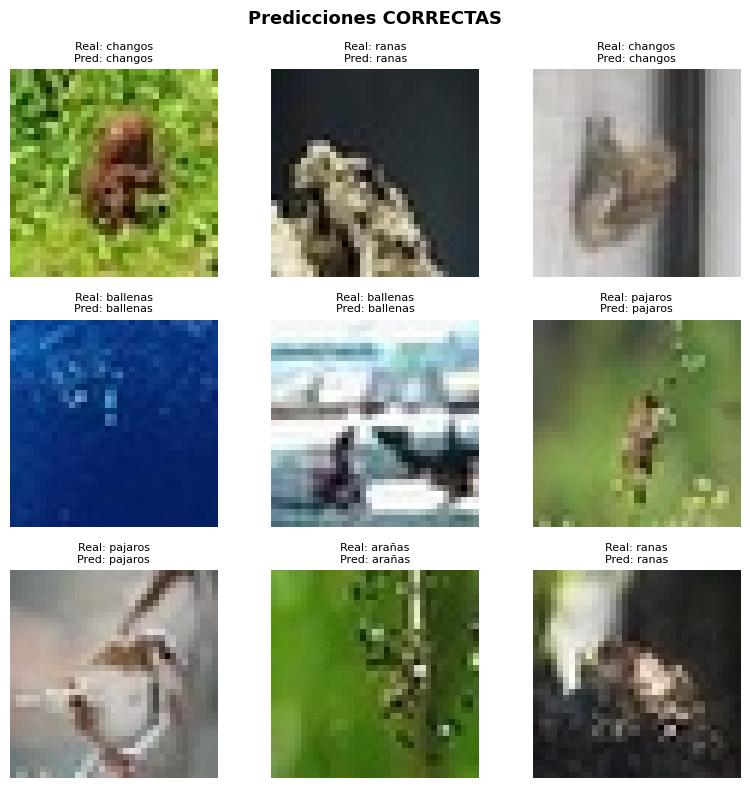

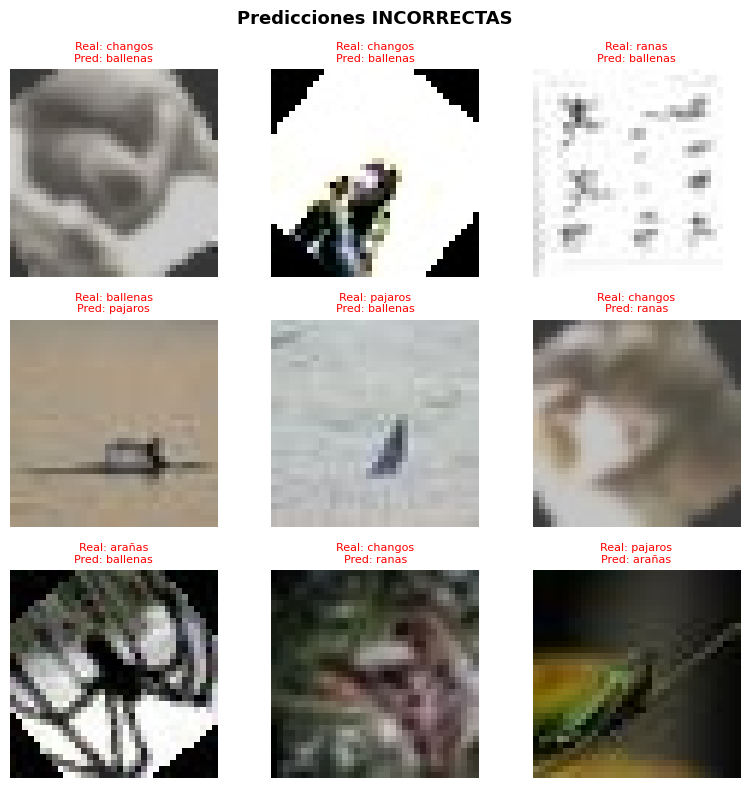

In [41]:
correct   = np.where(predicted_classes == test_Y)[0]
incorrect = np.where(predicted_classes != test_Y)[0]
print(f'Correctas:   {len(correct)}')
print(f'Incorrectas: {len(incorrect)}')

# Aciertos
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
fig.suptitle('Predicciones CORRECTAS', fontsize=13, fontweight='bold')
for i, idx in enumerate(correct[:9]):
    ax = axes[i // 3, i % 3]
    ax.imshow(test_X[idx])  
    ax.set_title(
        f'Real: {clases_nombres[test_Y[idx]]}\nPred: {clases_nombres[predicted_classes[idx]]}',
        fontsize=8
    )
    ax.axis('off')
plt.tight_layout()
plt.show()

# Errores
if len(incorrect) > 0:
    fig, axes = plt.subplots(3, 3, figsize=(8, 8))
    fig.suptitle('Predicciones INCORRECTAS', fontsize=13, fontweight='bold')
    for i, idx in enumerate(incorrect[:9]):
        ax = axes[i // 3, i % 3]
        ax.imshow(test_X[idx])   
        ax.set_title(
            f'Real: {clases_nombres[test_Y[idx]]}\nPred: {clases_nombres[predicted_classes[idx]]}',
            fontsize=8, color='red'
        )
        ax.axis('off')
    plt.tight_layout()
    plt.show()

---
# ════════════════════════════════════════
# DESDE AQUÍ SIN REENTRENAR MODELO
# ════════════════════════════════════════

# 18. Cargar Modelo Guardado

In [42]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

sport_model    = load_model('modelo_animales_final.keras')
clases_nombres = ['ranas', 'pajaros', 'ballenas', 'changos', 'arañas']

print('✅ Modelo cargado correctamente')
print('✅ Ejecuta la celda 19 para identificar un animal')

✅ Modelo cargado correctamente
✅ Ejecuta la celda 19 para identificar un animal


# 19. dentificar nuevas imagenes


 5 imagen(es) seleccionada(s)

🐾 Imagen 1: p6.jpeg
   Animal: PAJAROS  |  Confianza: 92.5%
   Probabilidades:
   ranas     :   0.4% 
   pajaros   :  92.5% ███████████████████████████
   ballenas  :   0.8% 
   changos   :   1.5% 
   arañas    :   4.9% █

🐾 Imagen 2: p7.jpeg
   Animal: PAJAROS  |  Confianza: 98.5%
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :  98.5% █████████████████████████████
   ballenas  :   0.0% 
   changos   :   0.0% 
   arañas    :   1.5% 

🐾 Imagen 3: p8.jpeg
   Animal: ARAÑAS  |  Confianza: 99.9%
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :   0.1% 
   ballenas  :   0.0% 
   changos   :   0.0% 
   arañas    :  99.9% █████████████████████████████

🐾 Imagen 4: p9.jpeg
   Animal: PAJAROS  |  Confianza: 87.8%
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :  87.8% ██████████████████████████
   ballenas  :   0.0% 
   changos   :   0.3% 
   arañas    :  11.8% ███

🐾 Imagen 5: p10.jpeg
   Animal: PAJAROS  |  Confianza: 97.7%
   Probabilida

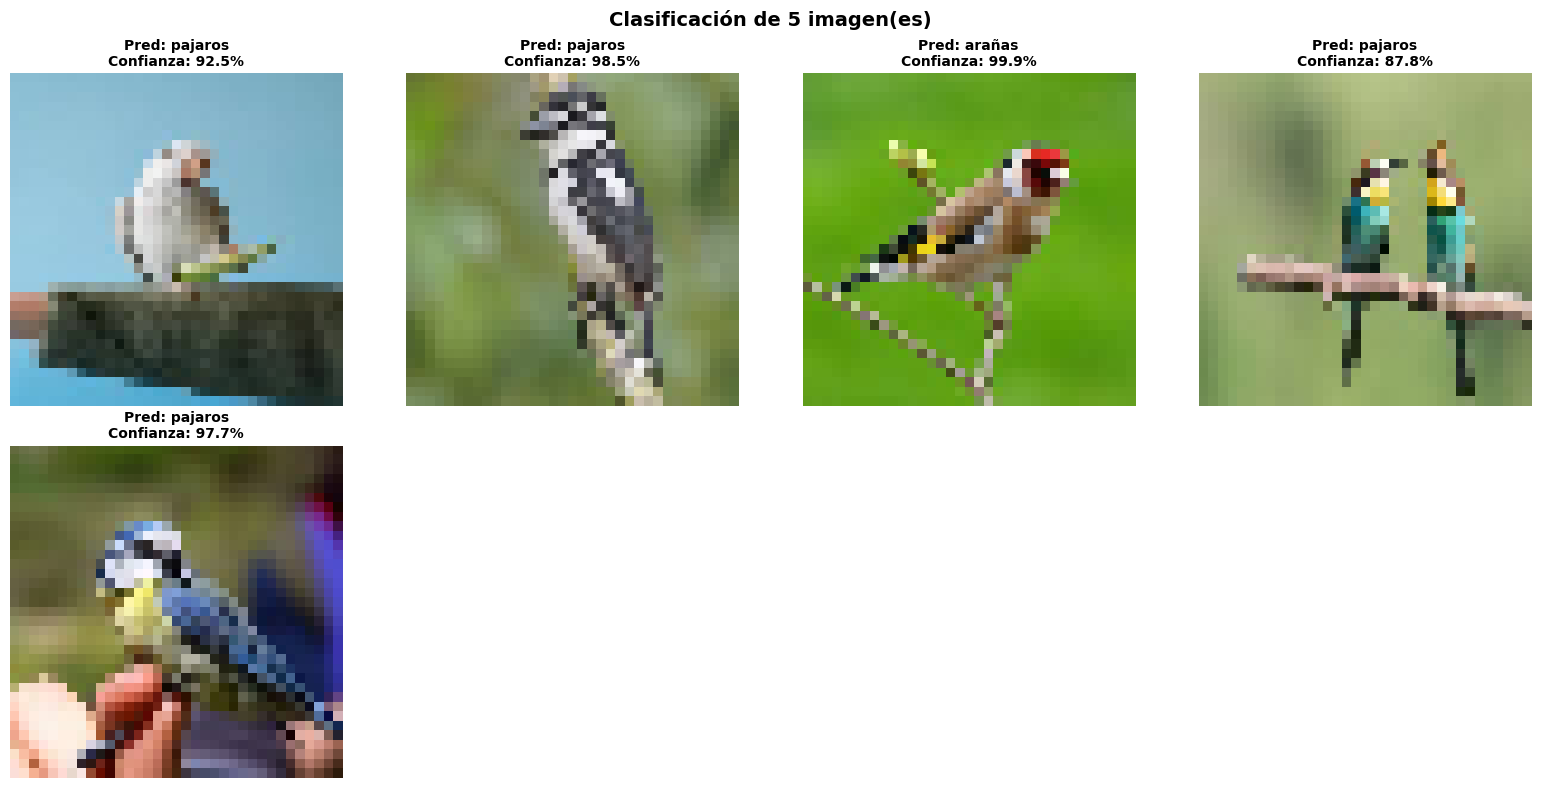

In [73]:
import tkinter as tk
from tkinter import filedialog
import os  

# En Ubuntu a veces tkinter no permite multi-selección,
# usamos options explícitas para forzarlo
root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True)

mis_imagenes = filedialog.askopenfilenames(
    title="Selecciona imágenes (Ctrl+Click para varias)",
    filetypes=[
        ("Imágenes", "*.jpg *.jpeg *.png *.bmp *.tiff"),
        ("Todos los archivos", "*.*")
    ],
    multiple=True  
)
root.destroy()

if not mis_imagenes:
    print(" No seleccionaste ninguna imagen.")
else:
    print(f" {len(mis_imagenes)} imagen(es) seleccionada(s)\n")

    n    = len(mis_imagenes)
    cols = min(n, 4)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))

    if n == 1:
        axes = [axes]
    else:
        axes = np.array(axes).flatten()

    for i, ruta in enumerate(mis_imagenes):
        img = cv2.imread(ruta)

        if img is None:
            print(f" No se pudo leer: {ruta}")
            axes[i].axis('off')
            continue

        img_rgb     = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, (35, 35))

        img_array  = img_resized.astype('float32') / 255.0
        img_array  = img_array.reshape(1, 35, 35, 3)

        prediccion = sport_model.predict(img_array, verbose=0)
        clase_idx  = np.argmax(prediccion)
        confianza  = prediccion[0][clase_idx] * 100

        axes[i].imshow(img_resized)
        axes[i].set_title(
            f'Pred: {clases_nombres[clase_idx]}\nConfianza: {confianza:.1f}%',
            fontsize=10, fontweight='bold'
        )
        axes[i].axis('off')

        print(f'🐾 Imagen {i+1}: {os.path.basename(ruta)}')
        print(f'   Animal: {clases_nombres[clase_idx].upper()}  |  Confianza: {confianza:.1f}%')
        print(f'   Probabilidades:')
        for clase, prob in zip(clases_nombres, prediccion[0]):
            barra = '█' * int(prob * 30)
            print(f'   {clase:<10}: {prob*100:5.1f}% {barra}')
        print()

    for j in range(n, len(axes)):
        axes[j].axis('off')

    plt.suptitle(f'Clasificación de {n} imagen(es)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()